# Plot Robustness Results

## Feature Importance Dropout

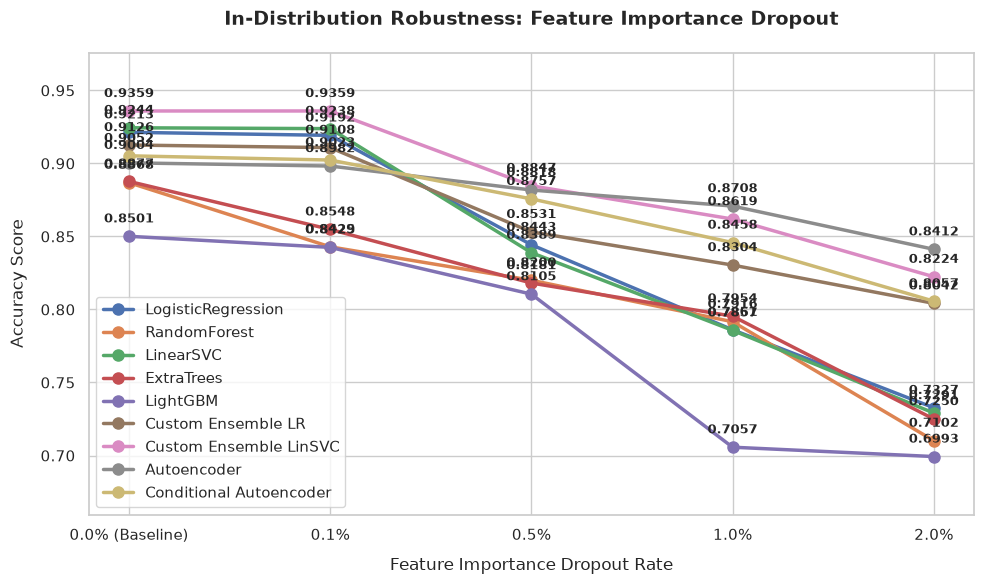

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

dropout_rates = ['0.0% (Baseline)', '0.1%', '0.5%', '1.0%', '2.0%']

data = {
    'LogisticRegression': [0.9213, 0.9192, 0.8443, 0.7861, 0.7327],
    'RandomForest': [0.8868, 0.8429, 0.8200, 0.7916, 0.7102], 
    'LinearSVC': [0.9244, 0.9238, 0.8389, 0.7857, 0.7291],
    'ExtraTrees': [0.8877, 0.8548, 0.8181, 0.7954, 0.7250],
    'LightGBM': [0.8501, 0.8425, 0.8105, 0.7057, 0.6993],
    'Custom Ensemble LR': [0.9126, 0.9108, 0.8531, 0.8304, 0.8042],
    'Custom Ensemble LinSVC': [0.9359, 0.9359, 0.8847, 0.8619, 0.8224],
    'Autoencoder': [0.9004, 0.8982, 0.8818, 0.8708, 0.8412],
    'Conditional Autoencoder': [0.9052, 0.9023, 0.8757, 0.8458, 0.8057],
}

plt.figure(figsize=(10, 6), dpi=100)

for model_name, accuracies in data.items():
    line = plt.plot(dropout_rates, accuracies, marker='o', linewidth=2.5, markersize=8, label=model_name)
    
    for i, acc in enumerate(accuracies):
        plt.annotate(
            f"{acc:.4f}", 
            (dropout_rates[i], acc), 
            textcoords="offset points", 
            xytext=(0, 10), 
            ha='center', 
            fontsize=9,
            fontweight='semibold'
        )

plt.xlabel('Feature Importance Dropout Rate', fontsize=12, labelpad=10)
plt.ylabel('Accuracy Score', fontsize=12, labelpad=10)
plt.title('In-Distribution Robustness: Feature Importance Dropout', fontsize=14, fontweight='bold', pad=20)

all_values = [val for accs in data.values() for val in accs]
plt.ylim(min(all_values) - 0.04, max(all_values) + 0.04)

plt.legend(loc='lower left', fontsize=11, frameon=True)

plt.tight_layout()

plt.savefig('in_distribution_robustness_comparison.png')

plt.show()

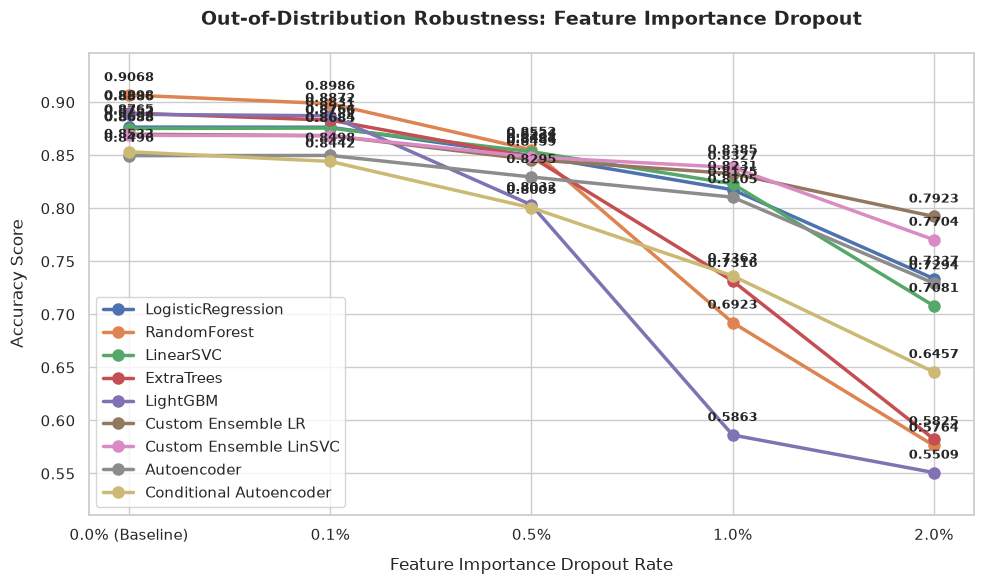

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

dropout_rates = ['0.0% (Baseline)', '0.1%', '0.5%', '1.0%', '2.0%']

data = {
    'LogisticRegression': [0.8765, 0.8764, 0.8497, 0.8175, 0.7337],
    'RandomForest': [0.9068, 0.8986, 0.8552, 0.6923, 0.5764], 
    'LinearSVC': [0.8752, 0.8756, 0.8534, 0.8231, 0.7081],
    'ExtraTrees': [0.8898, 0.8831, 0.8484, 0.7316, 0.5825],
    'LightGBM': [0.8886, 0.8872, 0.8032, 0.5863, 0.5509],
    'Custom Ensemble LR': [0.8698, 0.8685, 0.8459, 0.8327, 0.7923],
    'Custom Ensemble LinSVC': [0.8688, 0.8684, 0.8484, 0.8385, 0.7704],
    'Autoencoder': [0.8496, 0.8498, 0.8295, 0.8105, 0.7294],
    'Conditional Autoencoder': [0.8533, 0.8442, 0.8005, 0.7363, 0.6457],
}

plt.figure(figsize=(10, 6), dpi=100)

for model_name, accuracies in data.items():
    line = plt.plot(dropout_rates, accuracies, marker='o', linewidth=2.5, markersize=8, label=model_name)
    
    for i, acc in enumerate(accuracies):
        plt.annotate(
            f"{acc:.4f}", 
            (dropout_rates[i], acc), 
            textcoords="offset points", 
            xytext=(0, 10), 
            ha='center', 
            fontsize=9,
            fontweight='semibold'
        )

plt.xlabel('Feature Importance Dropout Rate', fontsize=12, labelpad=10)
plt.ylabel('Accuracy Score', fontsize=12, labelpad=10)
plt.title('Out-of-Distribution Robustness: Feature Importance Dropout', fontsize=14, fontweight='bold', pad=20)

all_values = [val for accs in data.values() for val in accs]
plt.ylim(min(all_values) - 0.04, max(all_values) + 0.04)

plt.legend(loc='lower left', fontsize=11, frameon=True)

plt.tight_layout()

plt.savefig('out_of_distribution_robustness_comparison.png')

plt.show()

## Scatter Plot with support

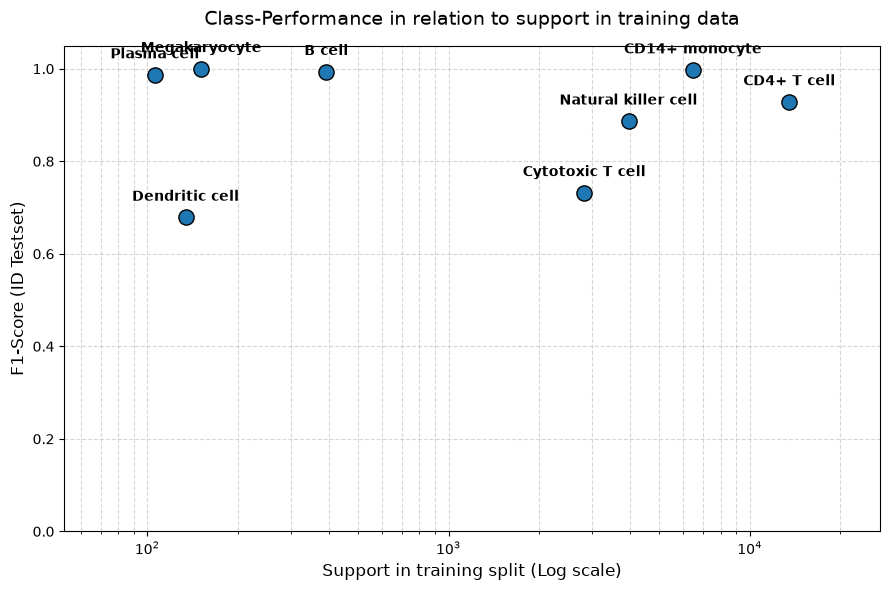

In [3]:
import matplotlib.pyplot as plt
import numpy as np

cell_types = ['CD4+ T cell', 'CD14+ monocyte', 'Natural killer cell', 'Cytotoxic T cell', 'B cell', 'Megakaryocyte', 'Dendritic cell', 'Plasma cell']
support_train = [13529, 6480, 3958, 2822, 393, 151, 134, 106]
f1_scores = [0.9284, 0.9973, 0.8866, 0.7319, 0.9937, 1.0, 0.6786, 0.9865]

plt.figure(figsize=(9, 6))

plt.scatter(support_train, f1_scores, color='#1f77b4', edgecolors='black', s=120, zorder=3, label='Mein Modell')

plt.xscale('log')

for i, txt in enumerate(cell_types):
    plt.annotate(txt, (support_train[i], f1_scores[i]), 
                 textcoords="offset points", 
                 xytext=(0, 12), 
                 ha='center', 
                 fontsize=10,
                 weight='bold')

plt.title('Class-Performance in relation to support in training data', fontsize=14, pad=15)
plt.xlabel('Support in training split (Log scale)', fontsize=12)
plt.ylabel('F1-Score (ID Testset)', fontsize=12)
plt.ylim(0, 1.05)
plt.xlim(min(support_train) * 0.5, max(support_train) * 2)

plt.grid(True, which="both", linestyle="--", alpha=0.5, zorder=1)

plt.tight_layout()
plt.show()

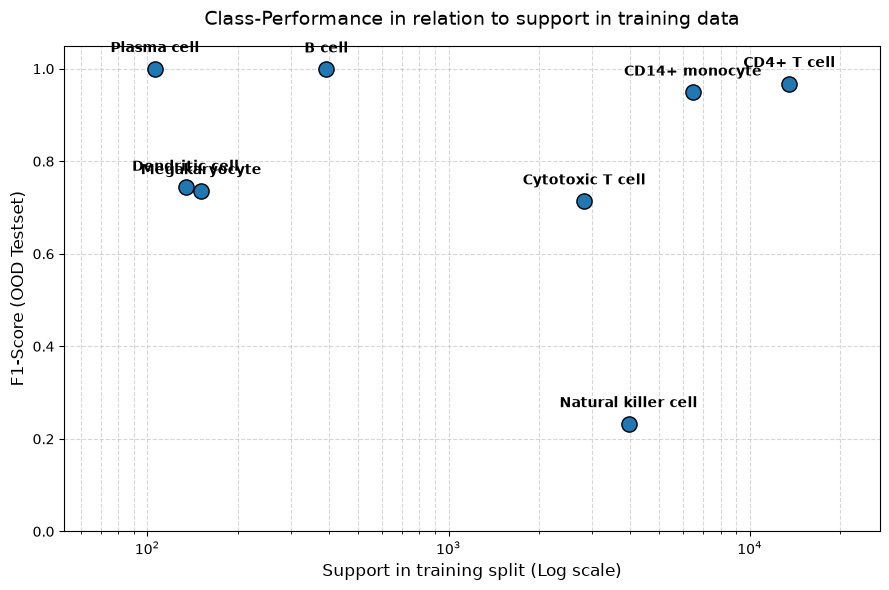

In [4]:
import matplotlib.pyplot as plt
import numpy as np

cell_types = ['CD4+ T cell', 'CD14+ monocyte', 'Natural killer cell', 'Cytotoxic T cell', 'B cell', 'Megakaryocyte', 'Dendritic cell', 'Plasma cell']
support_train = [13529, 6480, 3958, 2822, 393, 151, 134, 106]
f1_scores = [0.9676, 0.9492, 0.2325, 0.714, 0.9992, 0.7362, 0.7435, 1.0]

plt.figure(figsize=(9, 6))

plt.scatter(support_train, f1_scores, color='#1f77b4', edgecolors='black', s=120, zorder=3, label='Mein Modell')

plt.xscale('log')

for i, txt in enumerate(cell_types):
    plt.annotate(txt, (support_train[i], f1_scores[i]), 
                 textcoords="offset points", 
                 xytext=(0, 12), 
                 ha='center', 
                 fontsize=10,
                 weight='bold')

plt.title('Class-Performance in relation to support in training data', fontsize=14, pad=15)
plt.xlabel('Support in training split (Log scale)', fontsize=12)
plt.ylabel('F1-Score (OOD Testset)', fontsize=12)
plt.ylim(0, 1.05)
plt.xlim(min(support_train) * 0.5, max(support_train) * 2)

plt.grid(True, which="both", linestyle="--", alpha=0.5, zorder=1)

plt.tight_layout()
plt.show()

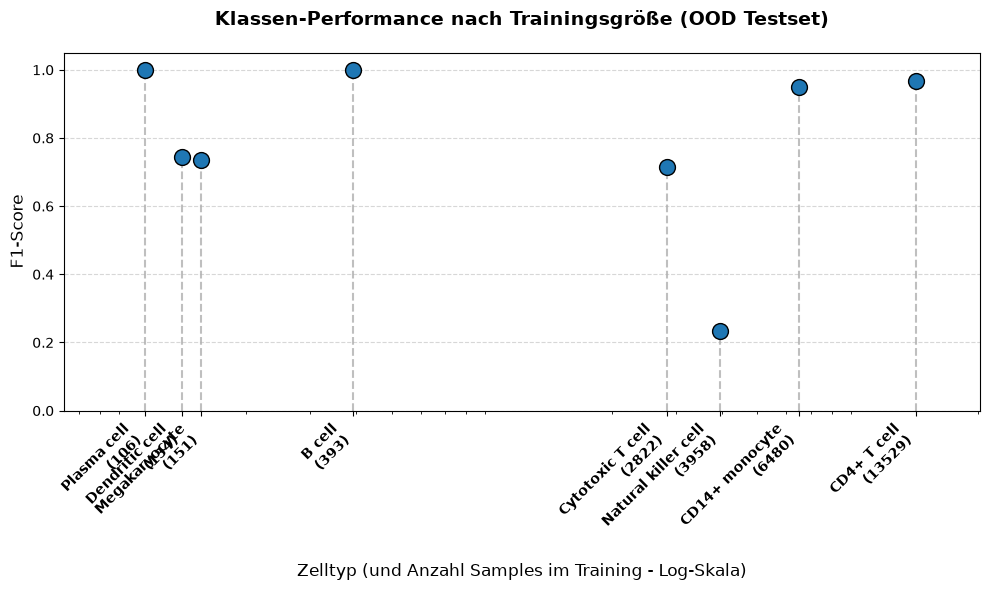

In [6]:
import matplotlib.pyplot as plt
import numpy as np

cell_types = ['CD4+ T cell', 'CD14+ monocyte', 'Natural killer cell', 'Cytotoxic T cell', 'B cell', 'Megakaryocyte', 'Dendritic cell', 'Plasma cell']
support_train = [13529, 6480, 3958, 2822, 393, 151, 134, 106]
f1_scores = [0.9676, 0.9492, 0.2325, 0.714, 0.9992, 0.7362, 0.7435, 1.0]

plt.figure(figsize=(10, 6))

plt.xscale('log')

plt.vlines(support_train, ymin=0, ymax=f1_scores, colors='gray', linestyles='dashed', alpha=0.5, zorder=1)

plt.scatter(support_train, f1_scores, color='#1f77b4', edgecolors='black', s=130, zorder=3, label='Mein Modell')

axis_labels = [f"{cell}\n({sup})" for cell, sup in zip(cell_types, support_train)]

plt.xticks(support_train, axis_labels, rotation=45, ha='right', fontsize=10, weight='bold')

plt.title('Klassen-Performance nach Trainingsgröße (OOD Testset)', fontsize=14, pad=20, weight='bold')
plt.xlabel('Zelltyp (und Anzahl Samples im Training - Log-Skala)', fontsize=12, labelpad=15)
plt.ylabel('F1-Score', fontsize=12)

plt.ylim(0, 1.05)
plt.xlim(min(support_train) * 0.6, max(support_train) * 1.5)

plt.grid(True, axis='y', linestyle='--', alpha=0.5, zorder=1)

plt.tight_layout()
plt.show()

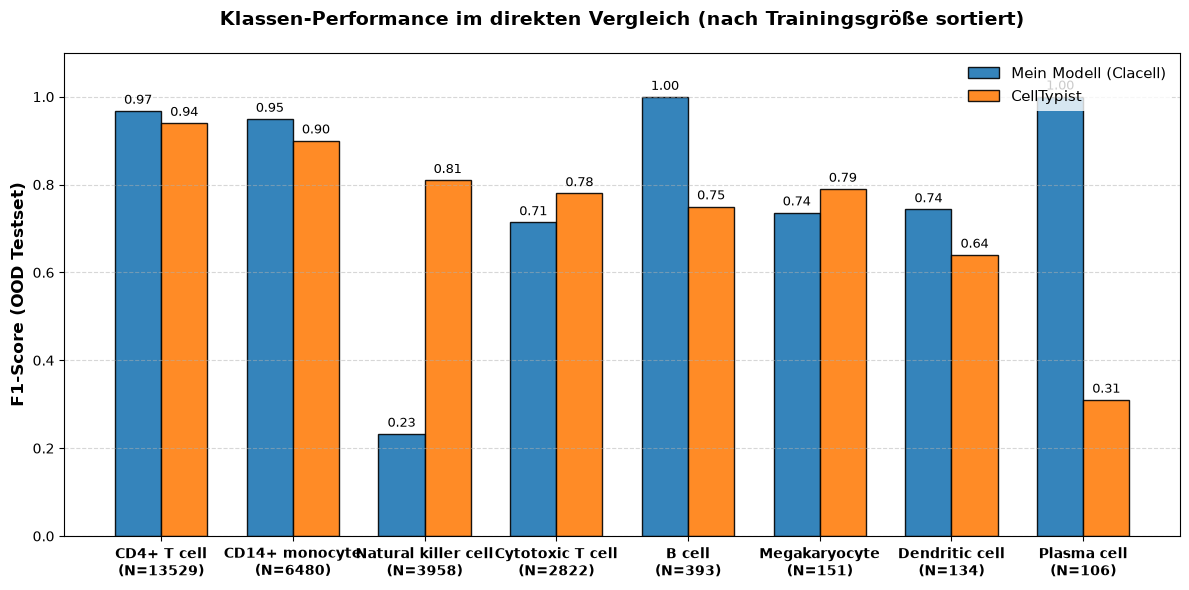

In [7]:
import matplotlib.pyplot as plt
import numpy as np

cell_types = ['CD4+ T cell', 'CD14+ monocyte', 'Natural killer cell', 'Cytotoxic T cell', 'B cell', 'Megakaryocyte', 'Dendritic cell', 'Plasma cell']
support_train = [13529, 6480, 3958, 2822, 393, 151, 134, 106]
f1_scores = [0.9676, 0.9492, 0.2325, 0.714, 0.9992, 0.7362, 0.7435, 1.0]

f1_celltypist_mock  = [0.94, 0.90, 0.81, 0.78, 0.75, 0.79, 0.64, 0.31]

x_labels = [f"{cell}\n(N={sup})" for cell, sup in zip(cell_types, support_train)]

x = np.arange(len(cell_types))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))

rects1 = ax.bar(x - width/2, f1_scores, width, label='Mein Modell (Clacell)', color='#1f77b4', edgecolor='black', alpha=0.9)
rects2 = ax.bar(x + width/2, f1_celltypist_mock, width, label='CellTypist', color='#ff7f0e', edgecolor='black', alpha=0.9)

ax.set_ylabel('F1-Score (OOD Testset)', fontsize=12, weight='bold')
ax.set_title('Klassen-Performance im direkten Vergleich (nach Trainingsgröße sortiert)', fontsize=14, pad=20, weight='bold')
ax.set_xticks(x)
ax.set_xticklabels(x_labels, fontsize=10, weight='bold')
ax.set_ylim(0, 1.1)

ax.grid(axis='y', linestyle='--', alpha=0.5)

ax.legend(loc='upper right', fontsize=11, frameon=True, facecolor='white', edgecolor='none')

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

autolabel(rects1)
autolabel(rects2)

plt.tight_layout()
plt.show()